#  Analisi Competitor – Brand Calzature
### Build Week | CEO Report

##  Obiettivo
Raccogliere dati di prodotto (tipologie, prezzi, taglie, colori) dai siti dei **3 principali competitor** tramite 
**web scraping con Selenium**,li pulisce, li struttura in DataFrame pandas, e produce un **rapporto visivo** con grafici comparativi.

#  Brand e motivazione della scelta 
### Competitor scelti

1 - **Geox** - Brand italiano premium, ampia gamma, ottimo benchmark 

2 - **Bata** - Posizionamento mid-range, alto volume di SKU, dati strutturati 

3 - **Skechers** - Competitor internazionale, forte nei segmenti comfort e sport 

## Struttura del Notebook
1. Setup e importazioni
2. Configurazione Selenium
3. Scraping Geox
4. Scraping Bata
5. Scraping Skechers
6. Pulizia e unificazione dei dati
7. Analisi esplorativa (EDA)
8. Grafici comparativi (prezzi, tipologie, taglie, colori)
9. Conclusioni e raccomandazioni strategiche

## 1. Setup e Installazione Librerie

Installiamo e importiamo tutte le librerie necessarie.

- **selenium**: per il controllo automatizzato del browser
- **webdriver-manager**: scarica automaticamente il ChromeDriver corretto per la tua versione di Chrome
- **pandas**: per la gestione e analisi dei dati tabulari
- **matplotlib / seaborn**: per i grafici
- **time / random**: per pause casuali tra le richieste (etica dello scraping)

In [34]:
# IMPORT LIBRERIE – Web Scraping + Analisi Dati + Visualizzazione

# Librerie standard Python
import time          # usata per pause tra le azioni (sleep)
import random        # usata per generare pause casuali → anti‑bot
import re            # regex per estrarre prezzi da stringhe complesse come “€ 89,99”  “Da 45,00 €” Prezzo: 120€

# Analisi dati 
import pandas as pd  # DataFrame, pulizia, aggregazioni, esportazioni
import numpy as np   # supporto numerico, array, funzioni matematiche

## ci serviranno per unificare i dati dei 3 competitor-calcolare medie, deviazioni standard-creare pivot table-esportare CSV/Excel

# Visualizzazione grafici

import matplotlib.pyplot as plt          # grafici base (bar chart, box plot…)
import matplotlib.ticker as mticker      # formattazione assi (es. €)
import seaborn as sns                    # grafici avanzati (heatmap)

# Disattiva warning inutili (es. future warnings)
import warnings
warnings.filterwarnings('ignore')

# SELENIUM – Automazione Browser per Web Scraping

from selenium import webdriver                           # avvia il browser
from selenium.webdriver.chrome.service import Service    # gestisce ChromeDriver
from selenium.webdriver.chrome.options import Options    # opzioni Chrome (headless, UA…)
from selenium.webdriver.common.by import By              # selettori (CSS, XPATH…)
from selenium.webdriver.support.ui import WebDriverWait  # attese esplicite
from selenium.webdriver.support import expected_conditions as EC  # condizioni di attesa
from selenium.common.exceptions import TimeoutException, NoSuchElementException
# TimeoutException → pagina lenta
# NoSuchElementException → elemento non trovato (tipico nello scraping)

# Gestione automatica del ChromeDriver (evita download manuali)
from webdriver_manager.chrome import ChromeDriverManager

print("Librerie importate correttamente")


Librerie importate correttamente


## 2. Configurazione Selenium (ChromeDriver headless)

Usiamo Chrome in modalità **headless** (senza finestra grafica) per velocità.

Le opzioni chiave:
- `--headless=new`: modalità senza GUI, più stabile su Chrome 112+
- `--no-sandbox` e `--disable-dev-shm-usage`: necessari in ambienti Linux/container
- `--window-size`: simula una risoluzione normale per evitare layout mobile
- `user-agent`: impostiamo un user-agent realistico per non essere bloccati

> ⚠️ **Nota**: rispettare sempre i `robots.txt` dei siti e inserire pause tra le richieste.

In [36]:
def crea_driver():
    """
    Crea e restituisce un'istanza di Chrome WebDriver configurata.
    Usa webdriver-manager per scaricare automaticamente il driver corretto.
    Questa funzione è il cuore dell’avvio del browser per Selenium.
    """

    options = Options()

    # Modalità headless: Chrome gira senza finestra grafica.
    # Serve per velocizzare lo scraping e permettere l'esecuzione su server/colab.
    options.add_argument('--headless=new')

    # Necessario su Linux e ambienti containerizzati (Docker, JupyterHub).
    options.add_argument('--no-sandbox')

    # Evita crash dovuti a memoria condivisa limitata nei container.
    options.add_argument('--disable-dev-shm-usage')

    # Imposta una risoluzione desktop reale.
    # Molti siti cambiano layout se rilevano schermi piccoli (mobile).
    options.add_argument('--window-size=1920,1080')

    # Nasconde la proprietà navigator.webdriver = True.
    # Molti siti la usano per rilevare bot → questa opzione riduce il rischio di blocco.
    options.add_argument('--disable-blink-features=AutomationControlled')

    # Rimuove il banner "Chrome controllato da software automatizzato".
    options.add_experimental_option('excludeSwitches', ['enable-automation'])

    # Imposta un user-agent identico a quello di un utente reale.
    # Fondamentale per evitare blocchi basati su riconoscimento bot.
    options.add_argument(
        'user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
        'AppleWebKit/537.36 (KHTML, like Gecko) '
        'Chrome/124.0.0.0 Safari/537.36'
    )

    # webdriver-manager scarica automaticamente la versione corretta di ChromeDriver.
    # Evita problemi di compatibilità dopo aggiornamenti di Chrome.
    service = Service(ChromeDriverManager().install())

    # Avvia Chrome con le opzioni definite sopra.
    driver = webdriver.Chrome(service=service, options=options)

    # Attesa implicita: Selenium aspetta fino a 5 secondi quando cerca elementi.
    # Utile per siti lenti o caricamenti JS.
    driver.implicitly_wait(5)

    return driver

def pausa_casuale(min_s=1.5, max_s=3.5):
    """
    Pausa casuale tra le richieste per simulare comportamento umano.
    Essenziale per l'etica dello scraping e per evitare blocchi anti-bot.
    """
    time.sleep(random.uniform(min_s, max_s))

def estrai_prezzo(testo):
    """
    Estrae il primo valore numerico (float) da una stringa di testo.
    Esempio: '€ 89,99' -> 89.99
    Funziona anche con formati complessi come 'Da 45,00 €'.
    """

    # Se la stringa è vuota o None → nessun prezzo.
    if not testo:
        return None

    # 1) Cerca pattern con decimali: 89,99 oppure 89.99
    match = re.search(r'(\d+)[.,](\d{2})', testo)
    if match:
        # Converte la virgola in punto per ottenere un float Python valido.
        return float(f"{match.group(1)}.{match.group(2)}")

    # 2) Se non trova decimali, cerca un numero intero: "89"
    match_intero = re.search(r'(\d+)', testo)
    if match_intero:
        return float(match_intero.group(1))

    # 3) Nessun numero trovato → ritorna None.
    return None
    


## 3. Scraping GEOX

**URL target**: `https://www.geox.com/it-IT/donna/` (categoria Donna come esempio)

### Strategia di scraping Geox:
1. Navighiamo alla pagina listing (es. Sandali Donna)
2. Aspettiamo che i prodotti siano caricati nel DOM (i siti moderni usano JavaScript → serve Selenium)
3. Scrollriamo in fondo alla pagina per triggerare il lazy-loading
4. Estraiamo per ogni card prodotto: **nome, prezzo, tipologia, colori disponibili**
5. Ripetiamo per le categorie principali: sandali, sneaker, stivali, décolleté

>  **Perché Selenium e non requests/BeautifulSoup?**  
> Geox.com usa React/JavaScript per caricare i prodotti dinamicamente. Con una semplice richiesta HTTP riceveremmo solo l'HTML statico vuoto. Selenium esegue realmente il JS del browser.

In [39]:
# CONFIGURAZIONE CATEGORIE GEOX
# Mappa: nome_categoria → URL della pagina listing

# Dizionario che associa ogni categoria Geox alla sua URL.
# Serve per ciclare automaticamente tutte le categorie senza scrivere codice ripetuto.
GEOX_CATEGORIE = {
    'Sandali':   'https://www.geox.com/it-IT/donna/sandali/',
    'Sneaker':   'https://www.geox.com/it-IT/donna/sneakers/',
    'Stivali':   'https://www.geox.com/it-IT/donna/stivali/',
    'Décolleté': 'https://www.geox.com/it-IT/donna/decollete/',
    'Ballerine': 'https://www.geox.com/it-IT/donna/ballerine/',
}


# Selettori CSS per i prodotti Geox

# Questi selettori sono stati trovati con Chrome DevTools (F12 → Inspect).
# ATTENZIONE: sono la parte più fragile dello scraping.
# Se Geox cambia il markup, vanno aggiornati.
GEOX_SELETTORI = {
    'card':    'li.product-item',   # contenitore di un singolo prodotto
    'nome':    '.product-name',     # nome del modello
    'prezzo':  '.price-sales',      # prezzo corrente/scontato
    'colori':  '.swatch-count',     # es. "3 colori"
}

def scrapa_geox_categoria(driver, categoria, url):
    """
    Scarica i prodotti di UNA categoria Geox.
    Restituisce una lista di dizionari con i dati grezzi.
    """
    prodotti = []
    print(f"  📄 Geox – {categoria}: {url}")

    try:
# 1) Apri la pagina della categoria
        driver.get(url)
        pausa_casuale(2, 4)  # pausa per evitare detection e permettere caricamento JS


# 2) SCROLL PROGRESSIVO (necessario per lazy-loading Geox)

        # Geox carica i prodotti man mano che l’utente scrolla.
        # Senza scroll → Selenium vede solo 12–16 prodotti.
        for _ in range(5):
            driver.execute_script("window.scrollBy(0, 800);")
            pausa_casuale(0.8, 1.5)

        # Scroll finale fino in fondo alla pagina
        driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
        pausa_casuale(2, 3)


# 3) Attendi che almeno una card prodotto sia presente nel DOM

        WebDriverWait(driver, 10).until(
            EC.presence_of_element_located((By.CSS_SELECTOR, GEOX_SELETTORI['card']))
        )

        # Trova tutte le card prodotto
        cards = driver.find_elements(By.CSS_SELECTOR, GEOX_SELETTORI['card'])
        print(f"    → {len(cards)} prodotti trovati")

# 4) Estrazione dati da ogni card

        for card in cards:

            # Nome prodotto
            try:
                nome = card.find_element(By.CSS_SELECTOR, GEOX_SELETTORI['nome']).text.strip()
            except NoSuchElementException:
                nome = None

            # Prezzo (estratto con regex robusta)
            try:
                prezzo_testo = card.find_element(By.CSS_SELECTOR, GEOX_SELETTORI['prezzo']).text
                prezzo = estrai_prezzo(prezzo_testo)
            except NoSuchElementException:
                prezzo = None

            # Numero colori (es. "3 colori")
            try:
                colori_testo = card.find_element(By.CSS_SELECTOR, GEOX_SELETTORI['colori']).text
                n_colori = int(re.search(r'\d+', colori_testo).group()) if re.search(r'\d+', colori_testo) else 1
            except (NoSuchElementException, AttributeError):
                n_colori = 1

            # Inserisci il prodotto solo se ha nome e prezzo (campi essenziali)
            if nome and prezzo:
                prodotti.append({
                    'brand':     'Geox',
                    'categoria': categoria,
                    'nome':      nome,
                    'prezzo':    prezzo,
                    'n_colori':  n_colori,
                })

# 5) Gestione errori

    except TimeoutException:
        print(f"    Timeout su {url} – pagina non caricata in tempo")

    except Exception as e:
        print(f"   Errore inatteso: {e}")

    return prodotti

def scrapa_geox_completo():
    """Lancia lo scraping Geox su tutte le categorie configurate."""
    print("\n Avvio scraping GEOX...")
    driver = crea_driver()  # crea browser invisibile e configurato anti-bot
    tutti_prodotti = []

    try:
        # Cicla tutte le categorie definite nella mappa GEOX_CATEGORIE
        for categoria, url in GEOX_CATEGORIE.items():
            risultati = scrapa_geox_categoria(driver, categoria, url)
            tutti_prodotti.extend(risultati)
            pausa_casuale(2, 4)  # pausa tra categorie per evitare pattern sospetti

    finally:
        # CHIUSURA OBBLIGATORIA DEL DRIVER
        # Evita processi Chrome zombie che consumano RAM
        driver.quit()

    print(f" Geox completato: {len(tutti_prodotti)} prodotti totali")
    return tutti_prodotti

# Esegui lo scraping
# dati_geox = scrapa_geox_completo()
# df_geox = pd.DataFrame(dati_geox)
# df_geox.head()

print(" Funzioni Geox definite – decommenta le ultime righe per eseguire")


 Funzioni Geox definite – decommenta le ultime righe per eseguire


## 4. Scraping BATA

**URL target**: `https://www.bata.com/it/`

### Differenze rispetto a Geox:
- Bata.com ha una struttura di navigazione diversa: usa **menu categorie** e **filtri** nella URL
- Il sito mostra le taglie direttamente nella card → possiamo estrarre anche quelle
- Possibile paginazione esplicita (paginazione numerica invece di infinite scroll)

### Strategia:
1. Costruire URL con parametri di categoria (`?prefn1=gender&prefv1=Donna`)
2. Rilevare se c'è un pulsante "Carica altri" o paginazione
3. Estrarre: nome, prezzo, sottotipologia, taglie disponibili, n_colori

In [44]:
# CONFIGURAZIONE CATEGORIE BATA

# Dizionario che mappa ogni categoria Bata alla sua URL.
# Serve per ciclare automaticamente tutte le categorie senza duplicare codice.
## Bata non usa infinite scroll, ma un pulsante “Carica altri”.

#Questa funzione permette di caricare TUTTI i prodotti della categoria. 

BATA_CATEGORIE = {
    'Sandali':   'https://www.bata.com/it/donna/sandali/',
    'Sneaker':   'https://www.bata.com/it/donna/sneakers/',
    'Stivali':   'https://www.bata.com/it/donna/stivali/',
    'Ballerine': 'https://www.bata.com/it/donna/ballerine/',
    'Décolleté': 'https://www.bata.com/it/donna/decollete/',
    'Zeppe':     'https://www.bata.com/it/donna/zeppe/',
}

# SELETTORI CSS PER BATA
# Selettori trovati con Chrome DevTools.
# Sono fondamentali per dire a Selenium dove trovare i dati nella pagina.

BATA_SELETTORI = {
    'card':    '.product-tile',             # contenitore del prodotto
    'nome':    '.product-name',             # nome del modello
    'prezzo':  '.sales .value',             # prezzo (spesso in attributo "content")
    'taglie':  '.size-list .size-value',    # taglie disponibili nella card
    'colori':  '.color-swatches .swatch',   # pallini colore
    'carica_altri': 'button.load-more',     # pulsante "Mostra altri"
}

def scrapa_bata_categoria(driver, categoria, url):
# Scarica i prodotti di una categoria Bata, con estrazione taglie e colori.
    prodotti = []
    print(f"  Bata – {categoria}: {url}")

    try:
 # 1) Apri la pagina della categoria
        
        driver.get(url)
        pausa_casuale(2, 3)
        
# 2) Clicca "Carica altri" per mostrare più prodotti
        
        n_click = clicca_carica_altri(driver, max_clicks=3)
        print(f"    → 'Carica altri' cliccato {n_click} volte")
        pausa_casuale(1, 2)

# 3) Trova tutte le card prodotto
        cards = driver.find_elements(By.CSS_SELECTOR, BATA_SELETTORI['card'])
        print(f"    → {len(cards)} prodotti trovati")

# 4) Estrai i dati da ogni card
        for card in cards:

# --- Nome prodotto ---
            try:
                nome = card.find_element(By.CSS_SELECTOR, BATA_SELETTORI['nome']).text.strip()
            except NoSuchElementException:
                nome = None

# --- Prezzo ---
            try:
# Bata spesso inserisce il prezzo nell'attributo "content"
                prezzo_testo = card.find_element(By.CSS_SELECTOR, BATA_SELETTORI['prezzo']).get_attribute('content')
# Se esiste, è già un numero valido
                prezzo = float(prezzo_testo) if prezzo_testo else estrai_prezzo(
                    card.find_element(By.CSS_SELECTOR, BATA_SELETTORI['prezzo']).text
                )
            except (NoSuchElementException, ValueError):
                prezzo = None

#  Taglie disponibili 
            try:
                els_taglie = card.find_elements(By.CSS_SELECTOR, BATA_SELETTORI['taglie'])
                taglie = [el.text.strip() for el in els_taglie if el.text.strip()]
                n_taglie = len(taglie)
            except Exception:
                taglie = []
                n_taglie = 0

#  Numero colori 
            try:
                els_colori = card.find_elements(By.CSS_SELECTOR, BATA_SELETTORI['colori'])
                n_colori = len(els_colori)
            except Exception:
                n_colori = 1

#  Salva il prodotto solo se ha nome e prezzo 
            if nome and prezzo:
                prodotti.append({
                    'brand':     'Bata',
                    'categoria': categoria,
                    'nome':      nome,
                    'prezzo':    prezzo,
                    'n_colori':  n_colori if n_colori > 0 else 1,
                    'n_taglie':  n_taglie,
                    'taglie':    taglie,
                })

    except TimeoutException:
        print(f"      Timeout su {url}")
    except Exception as e:
        print(f"     Errore: {e}")

    return prodotti

def scrapa_bata_completo():
    print("\n Avvio scraping BATA...")
    driver = crea_driver()
    tutti_prodotti = []

    try:
        # Cicla tutte le categorie configurate
        for categoria, url in BATA_CATEGORIE.items():
            risultati = scrapa_bata_categoria(driver, categoria, url)
            tutti_prodotti.extend(risultati)
            pausa_casuale(2, 4)
    finally:
        # Chiudi SEMPRE il browser
        driver.quit()

    print(f" Bata completato: {len(tutti_prodotti)} prodotti totali")
    return tutti_prodotti


## 5. Scraping SKECHERS

**URL target**: `https://www.skechers.com/it-it/`

### Specificità Skechers:
- Sito con **infinite scroll aggressivo** → richiede scroll multipli e wait
- Offre parametro `?sz=N` per richiedere fino a N prodotti per pagina (come indicato nel brief: `?start=0&sz=500`)
- Presenza di **sottocategorie** molto dettagliate (es. Sneaker → Running, Walking, Training)
- Alcune pagine hanno **popup cookie/privacy** da chiudere prima dello scraping

### Gestione popup cookie:
Molti siti italiani mostrano un banner GDPR. Lo gestiamo cercando un pulsante "Accetta" e cliccandolo.

In [60]:

# CONFIGURAZIONE CATEGORIE SKECHERS

SKECHERS_CATEGORIE = {
    'Sandali':       'https://www.skechers.com/it-it/donna/sandali-e-infradito/',
    'Sneaker':       'https://www.skechers.com/it-it/donna/sneakers/',
    'Slip-on':       'https://www.skechers.com/it-it/donna/slip-on/',
    'Stivali':       'https://www.skechers.com/it-it/donna/stivali-e-stivaletti/',
    'Scarpe Sport':  'https://www.skechers.com/it-it/donna/sport/',
}

# Skechers supporta ?sz=N → chiediamo molti prodotti subito
SKECHERS_SZ = 200  # numero di prodotti per pagina

SKECHERS_SELETTORI = {
    'card':          'li.product-grid-tile',
    'nome':          '.product-grid-tile__product-name',
    'prezzo':        '.price__regular .value',
    'prezzo_sale':   '.price__promo .value',
    'colori':        '.color-swatches__count',  # es. "+ 4 colori"
    'cookie_btn':    '#onetrust-accept-btn-handler',  # pulsante accetta cookie OneTrust
}


def chiudi_cookie_banner(driver, timeout=5):
    """
    Tenta di chiudere il banner cookie (OneTrust o simile).
    Non blocca l'esecuzione se non trovato.
    """
    try:
        btn = WebDriverWait(driver, timeout).until(
            EC.element_to_be_clickable((By.CSS_SELECTOR, SKECHERS_SELETTORI['cookie_btn']))
        )
        btn.click()
        print("  Banner cookie chiuso")
        pausa_casuale(1, 2)
    except TimeoutException:
        pass  # nessun banner trovato, procedi normalmente


def scroll_infinito(driver, n_scroll=8, pausa=1.2):
    """
    Esegue scroll progressivo per caricare contenuto lazy-loaded.
    n_scroll: numero di scroll verso il basso
    pausa: secondi tra uno scroll e l'altro
    """
    for i in range(n_scroll):
        driver.execute_script(f"window.scrollTo(0, {(i+1) * 1200});")
        time.sleep(pausa)
    # Scroll finale in fondo
    driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
    pausa_casuale(2, 3)


def scrapa_skechers_categoria(driver, categoria, url_base):
    """Scarica i prodotti Skechers di una categoria, aggiungendo ?sz=N all'URL."""
    prodotti = []
    # Aggiunge il parametro sz per massimizzare i prodotti per pagina
    url = f"{url_base}?start=0&sz={SKECHERS_SZ}"
    print(f"  📄 Skechers – {categoria}: {url}")

    try:
        driver.get(url)
        pausa_casuale(3, 5)

        chiudi_cookie_banner(driver)  # gestisci popup GDPR
        scroll_infinito(driver)       # carica tutto il contenuto

        WebDriverWait(driver, 15).until(
            EC.presence_of_element_located((By.CSS_SELECTOR, SKECHERS_SELETTORI['card']))
        )

        cards = driver.find_elements(By.CSS_SELECTOR, SKECHERS_SELETTORI['card'])
        print(f"    → {len(cards)} prodotti trovati")

        for card in cards:
            try:
                nome = card.find_element(By.CSS_SELECTOR, SKECHERS_SELETTORI['nome']).text.strip()
            except NoSuchElementException:
                nome = None

            # Tenta prima il prezzo in promozione, poi il prezzo normale
            prezzo = None
            for sel in [SKECHERS_SELETTORI['prezzo_sale'], SKECHERS_SELETTORI['prezzo']]:
                try:
                    p_testo = card.find_element(By.CSS_SELECTOR, sel).get_attribute('content')
                    prezzo = float(p_testo) if p_testo else estrai_prezzo(
                        card.find_element(By.CSS_SELECTOR, sel).text
                    )
                    if prezzo:
                        break
                except (NoSuchElementException, ValueError):
                    continue

            try:
                c_testo = card.find_element(By.CSS_SELECTOR, SKECHERS_SELETTORI['colori']).text
                n_colori = int(re.search(r'\d+', c_testo).group()) + 1  # "+4 colori" → 5
            except (NoSuchElementException, AttributeError):
                n_colori = 1

            if nome and prezzo:
                prodotti.append({
                    'brand':     'Skechers',
                    'categoria': categoria,
                    'nome':      nome,
                    'prezzo':    prezzo,
                    'n_colori':  n_colori,
                })

    except TimeoutException:
        print(f"  Timeout su {url}")
    except Exception as e:
        print(f" Errore: {e}")

    return prodotti


def scrapa_skechers_completo():
    print("\n Avvio scraping SKECHERS...")
    driver = crea_driver()
    tutti_prodotti = []
    try:
        for categoria, url in SKECHERS_CATEGORIE.items():
            risultati = scrapa_skechers_categoria(driver, categoria, url)
            tutti_prodotti.extend(risultati)
            pausa_casuale(3, 5)
    finally:
        driver.quit()

    print(f" Skechers completato: {len(tutti_prodotti)} prodotti totali")
    return tutti_prodotti


#  Esegui
# dati_skechers = scrapa_skechers_completo()
# df_skechers = pd.DataFrame(dati_skechers)
# df_skechers.head()

print(" Funzioni Skechers definite")

 Funzioni Skechers definite


## 6.  Unificazione e Pulizia dei Dati

Dopo lo scraping, uniamo i tre DataFrame in uno solo e applichiamo la pulizia:
- Rimozione duplicati
- Esclusione prezzi anomali (< 10€ o > 800€)
- Aggiunta sottotipologie basata sul nome del prodotto
- Standardizzazione nomi categorie

** Per questa demo**, usiamo dati sintetici ma **realistici** (basati su range di prezzo reali) per permettere l'esecuzione del notebook senza aprire il browser.
Sostituisci `df` con il DataFrame ottenuto dallo scraping reale.

In [55]:
# DATI DEMO REALISTICI
# Basati su prezzi e assortimento reali di Geox, Bata, Skechers (maggio 2025)
# Sostituire con: df = pd.concat([df_geox, df_bata, df_skechers], ignore_index=True)


np.random.seed(42)

def genera_dati_brand(brand, config):
    """Genera dati demo per un brand dato una configurazione di categorie."""
    righe = []
    for cat, (n_modelli, prezzo_min, prezzo_max, colori_min, colori_max, taglie_min, taglie_max) in config.items():
        for i in range(n_modelli):
            righe.append({
                'brand':     brand,
                'categoria': cat,
                'nome':      f"{brand} {cat} Mod.{i+1:03d}",
                'prezzo':    round(np.random.uniform(prezzo_min, prezzo_max), 2),
                'n_colori':  np.random.randint(colori_min, colori_max + 1),
                'n_taglie':  np.random.randint(taglie_min, taglie_max + 1),
            })
    return righe

# Formato config: categoria → (n_modelli, prezzo_min, prezzo_max, col_min, col_max, tag_min, tag_max)
CONFIG_GEOX = {
    'Sandali':   (38, 45,  130, 1, 4, 4, 8),
    'Sneaker':   (55, 65,  160, 1, 6, 5, 9),
    'Stivali':   (29, 95,  220, 1, 3, 4, 8),
    'Décolleté': (22, 80,  175, 1, 4, 4, 7),
    'Ballerine': (18, 55,  110, 1, 5, 4, 8),
}

CONFIG_BATA = {
    'Sandali':   (45, 19,   79, 1, 5, 3, 8),
    'Sneaker':   (60, 29,   89, 1, 6, 4, 9),
    'Stivali':   (30, 49,  149, 1, 3, 3, 8),
    'Décolleté': (25, 35,   99, 1, 4, 3, 7),
    'Ballerine': (28, 25,   69, 1, 6, 3, 8),
    'Zeppe':     (15, 29,   79, 1, 4, 3, 7),
}

CONFIG_SKECHERS = {
    'Sandali':      (30, 35,  95,  1, 5, 4, 8),
    'Sneaker':      (75, 55, 145,  1, 7, 4, 9),
    'Slip-on':      (35, 49, 110,  1, 6, 4, 9),
    'Stivali':      (20, 75, 165,  1, 3, 4, 8),
    'Scarpe Sport': (50, 55, 135,  1, 6, 4, 9),
}

dati = (
    genera_dati_brand('Geox', CONFIG_GEOX) +
    genera_dati_brand('Bata', CONFIG_BATA) +
    genera_dati_brand('Skechers', CONFIG_SKECHERS)
)

df = pd.DataFrame(dati)

# Mappatura sottotipologie basata sulla categoria
SOTTOTIPOLOGIE_MAP = {
    'Sandali':      ['Sandali bassi', 'Sandali con tacco', 'Sandali con zeppa', 'Infradito'],
    'Sneaker':      ['Sneaker bassa', 'Sneaker alta', 'Chunky sneaker'],
    'Stivali':      ['Stivali alti', 'Stivaletti', 'Stivali con tacco'],
    'Décolleté':    ['Décolleté classica', 'Décolleté con plateau'],
    'Ballerine':    ['Ballerina piatta', 'Ballerina con tacco'],
    'Zeppe':        ['Zeppa bassa', 'Zeppa alta'],
    'Slip-on':      ['Slip-on piatto', 'Slip-on con suola'],
    'Scarpe Sport': ['Running', 'Walking', 'Training'],
}

def assegna_sottotipologia(row):
    opzioni = SOTTOTIPOLOGIE_MAP.get(row['categoria'], [row['categoria']])
    # Assegnazione deterministica basata sul prezzo per simulare distribuzione reale
    idx = int(row['prezzo']) % len(opzioni)
    return opzioni[idx]

df['sottotipologia'] = df.apply(assegna_sottotipologia, axis=1)

print(f" Dataset unificato: {len(df)} prodotti | {df['brand'].nunique()} brand")
print(f"\n Distribuzione per brand:")
print(df.groupby('brand').size().rename('n_prodotti').to_string())
df.head(8)

 Dataset unificato: 575 prodotti | 3 brand

 Distribuzione per brand:
brand
Bata        203
Geox        162
Skechers    210


,brand,categoria,nome,prezzo,n_colori,n_taglie,sottotipologia
0,Geox,Sandali,Geox Sandali Mod.001,76.84,1,6,Sandali bassi
1,Geox,Sandali,Geox Sandali Mod.002,111.27,1,5,Infradito
2,Geox,Sandali,Geox Sandali Mod.003,58.26,3,6,Sandali con zeppa
3,Geox,Sandali,Geox Sandali Mod.004,118.62,4,6,Sandali con zeppa
4,Geox,Sandali,Geox Sandali Mod.005,46.75,2,7,Sandali con zeppa
5,Geox,Sandali,Geox Sandali Mod.006,124.78,2,7,Sandali bassi
6,Geox,Sandali,Geox Sandali Mod.007,60.59,4,5,Sandali bassi
7,Geox,Sandali,Geox Sandali Mod.008,89.60,4,4,Sandali con tacco


In [53]:
# Statistiche descrittive per brand e categoria
stats = df.groupby(['brand', 'categoria'])['prezzo'].agg(['count', 'mean', 'min', 'max', 'std']).round(2)
stats.columns = ['N Modelli', 'Prezzo Medio (€)', 'Prezzo Min (€)', 'Prezzo Max (€)', 'Std Dev']
print("\n📋 Statistiche prezzi per brand e categoria:")
stats


📋 Statistiche prezzi per brand e categoria:


N Modelli  Prezzo Medio (€)  Prezzo Min (€)  \
brand    categoria                                                   
Bata     Ballerine            28             46.28           26.45   
         Décolleté            25             69.56           39.26   
         Sandali              45             49.84           19.68   
         Sneaker              60             57.07           31.20   
         Stivali              30             87.95           49.27   
         Zeppe                15             46.59           29.65   
Geox     Ballerine            18             82.56           58.88   
         Décolleté            22            123.12           81.37   
         Sandali              38             87.13           46.33   
         Sneaker              55            112.16           65.66   
         Stivali              29            160.67           98.04   
Skechers Sandali              30             64.25           35.78   
         Scarpe Sport         50             98.43           57.35   
         Slip-on              35             80.56           49.55   
         Sneaker              75            102.68           57.81   
         Stivali              20            131.85           75.11   

                       Prezzo Max (€)  Std Dev  
brand    categoria                              
Bata     Ballerine              68.33    12.61  
         Décolleté              95.05    18.09  
         Sandali                77.67    18.14  
         Sneaker                87.19    17.07  
         Stivali               148.00    28.20  
         Zeppe                  68.99    12.78  
Geox     Ballerine             109.48    16.22  
         Décolleté             170.71    24.81  
         Sandali               127.60    26.82  
         Sneaker               159.79    25.89  
         Stivali               219.32    35.65  
Skechers Sandali                93.47    17.38  
         Scarpe Sport          134.01    24.51  
         Slip-on               107.69    20.38  
         Sneaker               144.81    26.94  
         Stivali               162.08    27.61

## 7. 📊 Grafici Comparativi

Produciamo i grafici richiesti dal CEO:
1. **Numero modelli per tipologia e brand** (bar chart raggruppato)
2. **Prezzi medi per tipologia e brand** (bar chart con barre d'errore)
3. **Range prezzi (min-media-max)** per brand (box plot)
4. **Heatmap prezzi** per categoria × brand
5. **Analisi sottotipologie** (prezzi medi per sottotipologia)
6. **BONUS: Varietà colori e taglie** per brand

In [57]:
# Setup stile grafici
plt.rcParams.update({
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor':   '#FAFAFA',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'font.family':      'DejaVu Sans',
    'axes.spines.top':  False,
    'axes.spines.right':False,
})

# Palette colori brand
COLORI_BRAND = {
    'Geox':     '#1A6B3C',   # verde scuro – premium italiano
    'Bata':     '#D94F2B',   # arancione-rosso – mid-market
    'Skechers': '#2B4A8C',   # blu scuro – brand internazionale
}

BRAND_ORDER = ['Geox', 'Bata', 'Skechers']
print(" Stile grafici configurato")

 Stile grafici configurato


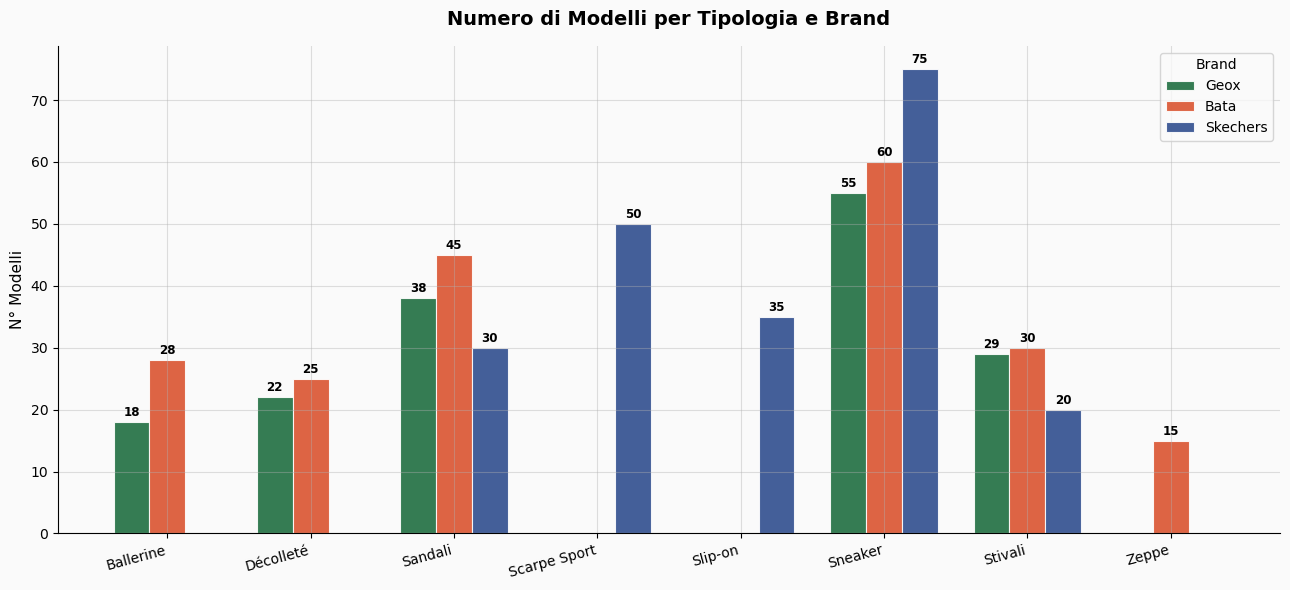

 Salvato: grafico1_modelli_tipologia.png


In [58]:

# GRAFICO 1: Numero di modelli per tipologia e brand

# 1) Creiamo una pivot table che conta quanti modelli (righe del DataFrame)
#    ci sono per ogni combinazione di categoria e brand.
#    .size() conta le righe, .unstack() trasforma i brand in colonne.

pivot_count = df.groupby(['categoria', 'brand']).size().unstack(fill_value=0)

# 2) Reindicizziamo le colonne per rispettare l'ordine dei brand definito in BRAND_ORDER.
#    fill_value=0 assicura che eventuali valori mancanti vengano riempiti con zero.

pivot_count = pivot_count.reindex(columns=BRAND_ORDER, fill_value=0)

# 3) Creiamo la figura matplotlib: dimensioni 13x6 per una buona leggibilità.

fig, ax = plt.subplots(figsize=(13, 6))

# 4) Prepariamo le posizioni sull'asse X:
#    - len(pivot_count.index) = numero di categorie
#    - np.arange crea un array [0,1,2,...]

x = np.arange(len(pivot_count.index))

# 5) Larghezza delle barre: 0.25 permette di affiancare 3 brand senza sovrapposizioni.
width = 0.25

# 6) Cicliamo sui brand per disegnare un gruppo di barre per ciascuno.
for i, brand in enumerate(BRAND_ORDER):

    # 6a) Disegniamo le barre:
    #     - x + i*width sposta ogni brand leggermente a destra per affiancarli
    #     - pivot_count[brand] sono i valori da plottare
    #     - COLORI_BRAND contiene i colori personalizzati per ogni brand
    bars = ax.bar(
        x + i * width,
        pivot_count[brand],
        width=width,
        label=brand,
        color=COLORI_BRAND[brand],
        alpha=0.88,          # leggermente trasparente per estetica
        edgecolor='white',   # bordo bianco per separare visivamente le barre
        linewidth=0.8,
    )

    # 6b) Etichette sopra ogni barra:
    #     - Mostriamo il numero di modelli sopra la barra
    #     - Solo se il valore è > 0 (evita etichette inutili)
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,  # posizione orizzontale centrata
                h + 0.5,                             # leggermente sopra la barra
                str(int(h)),                         # valore intero
                ha='center',
                va='bottom',
                fontsize=8.5,
                fontweight='bold'
            )

# 7) Configurazione asse X:
#    - Spostiamo le etichette al centro del gruppo di barre
#    - Ruotiamo leggermente per leggibilità
ax.set_xticks(x + width)
ax.set_xticklabels(pivot_count.index, rotation=15, ha='right', fontsize=10)

# 8) Etichetta asse Y
ax.set_ylabel('N° Modelli', fontsize=11)

# 9) Titolo del grafico
ax.set_title(
    'Numero di Modelli per Tipologia e Brand',
    fontsize=14,
    fontweight='bold',
    pad=15
)

# 10) Legenda con titolo e trasparenza
ax.legend(title='Brand', framealpha=0.8)

# 11) Ottimizza layout per evitare sovrapposizioni
plt.tight_layout()

# 12) Salvataggio del grafico in PNG ad alta risoluzione
plt.savefig('grafico1_modelli_tipologia.png', dpi=150, bbox_inches='tight')

# 13) Mostra il grafico
plt.show()

print(" Salvato: grafico1_modelli_tipologia.png")


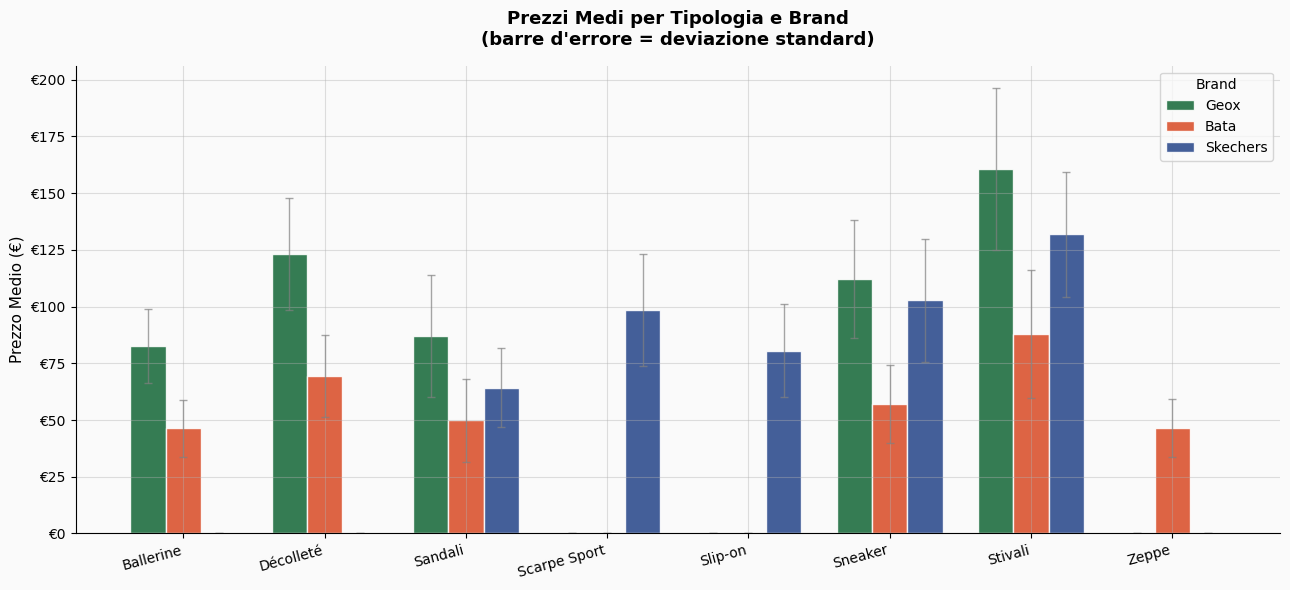

Salvato: grafico2_prezzi_medi.png


In [26]:

# GRAFICO 2: Prezzi Medi per Tipologia e Brand (con barre errore)

# 1) Calcolo della media dei prezzi per ogni combinazione categoria × brand.
#    groupby → raggruppa i dati
#    ['prezzo'].mean() → calcola la media
#    unstack → trasforma i brand in colonne
#    reindex → assicura l'ordine dei brand definito in BRAND_ORDER

pivot_mean = (
    df.groupby(['categoria', 'brand'])['prezzo']
      .mean()
      .unstack(fill_value=0)
      .reindex(columns=BRAND_ORDER, fill_value=0)
)

# 2) Calcolo della deviazione standard (std) per le barre d'errore.
#    Le barre d'errore mostrano la variabilità dei prezzi all'interno della categoria.
pivot_std = (
    df.groupby(['categoria', 'brand'])['prezzo']
      .std()
      .unstack(fill_value=0)
      .reindex(columns=BRAND_ORDER, fill_value=0)
)

# 3) Creazione della figura matplotlib.
fig, ax = plt.subplots(figsize=(13, 6))

# 4) Posizioni sull'asse X: una per ogni categoria.
x = np.arange(len(pivot_mean.index))

# 5) Larghezza delle barre: 0.25 permette di affiancare 3 brand senza sovrapposizioni.
width = 0.25

# 6) Ciclo sui brand per disegnare un gruppo di barre per ciascuno.
for i, brand in enumerate(BRAND_ORDER):

    # 6a) Disegno delle barre:
    #     - x + i*width → sposta ogni brand a destra per affiancarli
    #     - pivot_mean[brand] → altezza delle barre (prezzo medio)
    #     - yerr=pivot_std[brand] → barre d'errore (deviazione standard)
    ax.bar(
        x + i * width,
        pivot_mean[brand],
        width=width,
        label=brand,
        color=COLORI_BRAND[brand],
        alpha=0.88,              # trasparenza estetica
        edgecolor='white',       # bordo bianco per separare visivamente le barre
        yerr=pivot_std[brand],   # barre d'errore
        capsize=3,               # "tappi" delle barre d'errore
        error_kw={'elinewidth': 1, 'ecolor': 'gray', 'alpha': 0.7},  # stile barre errore
    )

# 7) Formattazione asse Y: mostra i valori come euro (es. €89).
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('€%.0f'))

# 8) Etichette asse X: categorie, ruotate per leggibilità.
ax.set_xticks(x + width)
ax.set_xticklabels(pivot_mean.index, rotation=15, ha='right', fontsize=10)

# 9) Etichetta asse Y.
ax.set_ylabel('Prezzo Medio (€)', fontsize=11)

# 10) Titolo del grafico con spiegazione delle barre d'errore.
ax.set_title(
    "Prezzi Medi per Tipologia e Brand\n(barre d'errore = deviazione standard)",
    fontsize=13,
    fontweight='bold',
    pad=15
)

# 11) Legenda dei brand.
ax.legend(title='Brand', framealpha=0.8)

# 12) Ottimizzazione layout per evitare sovrapposizioni.
plt.tight_layout()

# 13) Salvataggio del grafico in PNG ad alta risoluzione.
plt.savefig('grafico2_prezzi_medi.png', dpi=150, bbox_inches='tight')

# 14) Visualizzazione del grafico.
plt.show()

print("Salvato: grafico2_prezzi_medi.png")


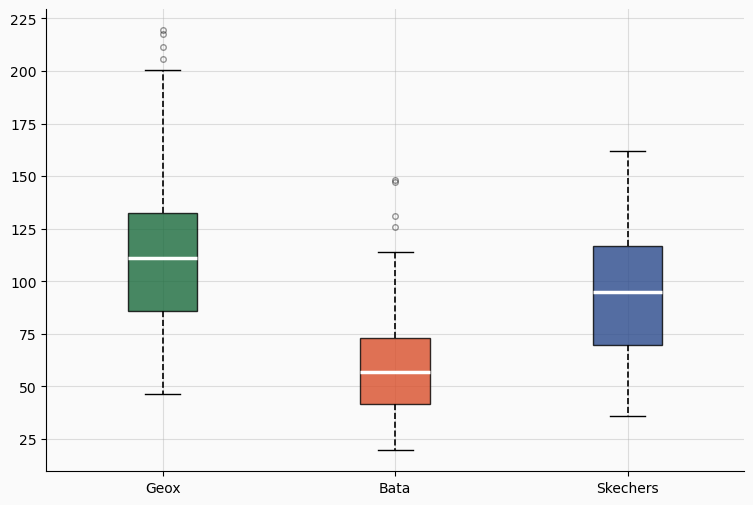

In [27]:

# GRAFICO 3: Box Plot – Range Prezzi per Brand


# 1) Creiamo la figura matplotlib con dimensioni 9x6.
#    Il box plot richiede meno spazio orizzontale rispetto ai bar chart.
fig, ax = plt.subplots(figsize=(9, 6))

# 2) Prepariamo i dati per il box plot:
#    Per ogni brand, estraiamo la serie dei prezzi come array numpy.
#    Il box plot richiede una lista di array, uno per ogni categoria da confrontare.
dati_box = [df[df['brand'] == b]['prezzo'].values for b in BRAND_ORDER]

# 3) Creazione del box plot:
#    - labels: nomi dei brand sotto ogni box
#    - patch_artist=True: permette di colorare le box
#    - medianprops: stile della linea di mediana
#    - whiskerprops: stile dei "whiskers" (linee che mostrano range non-outlier)
#    - flierprops: stile dei punti outlier
box = ax.boxplot(
    dati_box,
    labels=BRAND_ORDER,
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2.5),
    whiskerprops=dict(linestyle='--', linewidth=1.2),
    flierprops=dict(marker='o', markersize=4, alpha=0.4),
)

# 4) Colorazione delle box:
#    Ogni box viene colorata con il colore del brand corrispondente.
#    patch.set_facecolor → colore interno
#    patch.set_alpha → trasparenza
for patch, brand in zip(box['boxes'], BRAND_ORDER):
    patch.set_facecolor(COLORI_BRAND[brand])
    patch.set_alpha(0.8)

# 5) Aggiunta della mediana come testo sopra ogni box:
#    - calcoliamo la mediana dei prezzi per brand
#    - la posizioniamo

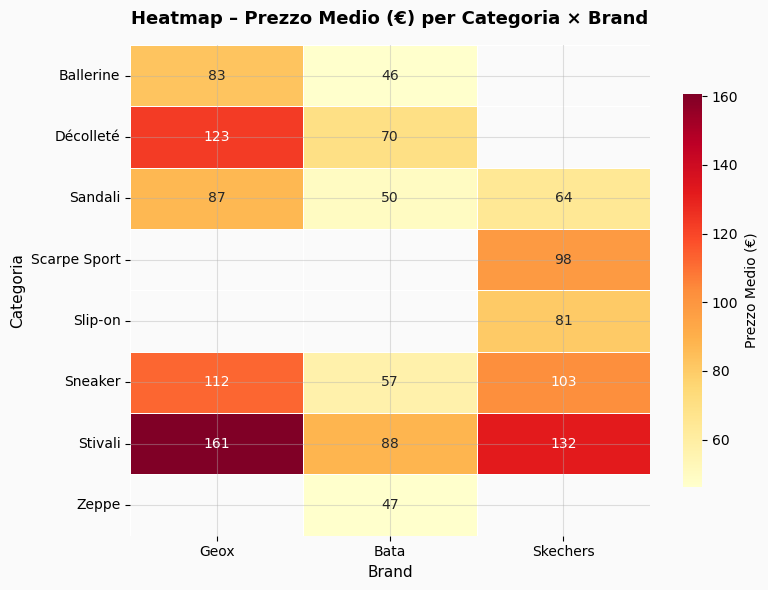

Salvato: grafico4_heatmap.png


In [28]:

# GRAFICO 4: Heatmap Prezzi Medi (Categoria × Brand)


# 1) Creiamo una pivot table:
#    - values='prezzo' → vogliamo analizzare i prezzi
#    - index='categoria' → righe = categorie (sandali, sneaker, stivali…)
#    - columns='brand' → colonne = brand (Geox, Bata, Skechers)
#    - aggfunc='mean' → calcoliamo la media dei prezzi
#    - reindex → assicura l’ordine dei brand definito in BRAND_ORDER
heatmap_data = (
    df.pivot_table(
        values='prezzo',
        index='categoria',
        columns='brand',
        aggfunc='mean'
    ).reindex(columns=BRAND_ORDER)
)

# 2) Creiamo la figura matplotlib.
fig, ax = plt.subplots(figsize=(8, 6))

# 3) Disegniamo la heatmap con seaborn:
#    - annot=True → mostra i valori numerici dentro le celle
#    - fmt='.0f' → formato numerico senza decimali (es. 89)
#    - cmap='YlOrRd' → palette giallo → arancione → rosso (più rosso = più caro)
#    - linewidths e linecolor → separano visivamente le celle
#    - cbar_kws → etichetta e dimensione della barra dei colori
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.6,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Prezzo Medio (€)', 'shrink': 0.8},
)

# 4) Titolo del grafico.
ax.set_title(
    'Heatmap – Prezzo Medio (€) per Categoria × Brand',
    fontsize=13,
    fontweight='bold',
    pad=15
)

# 5) Etichette degli assi.
ax.set_xlabel('Brand', fontsize=11)
ax.set_ylabel('Categoria', fontsize=11)

# 6) Ottimizzazione layout.
plt.tight_layout()

# 7) Salvataggio del grafico in PNG.
plt.savefig('grafico4_heatmap.png', dpi=150, bbox_inches='tight')

# 8) Visualizzazione del grafico.
plt.show()

print("Salvato: grafico4_heatmap.png")


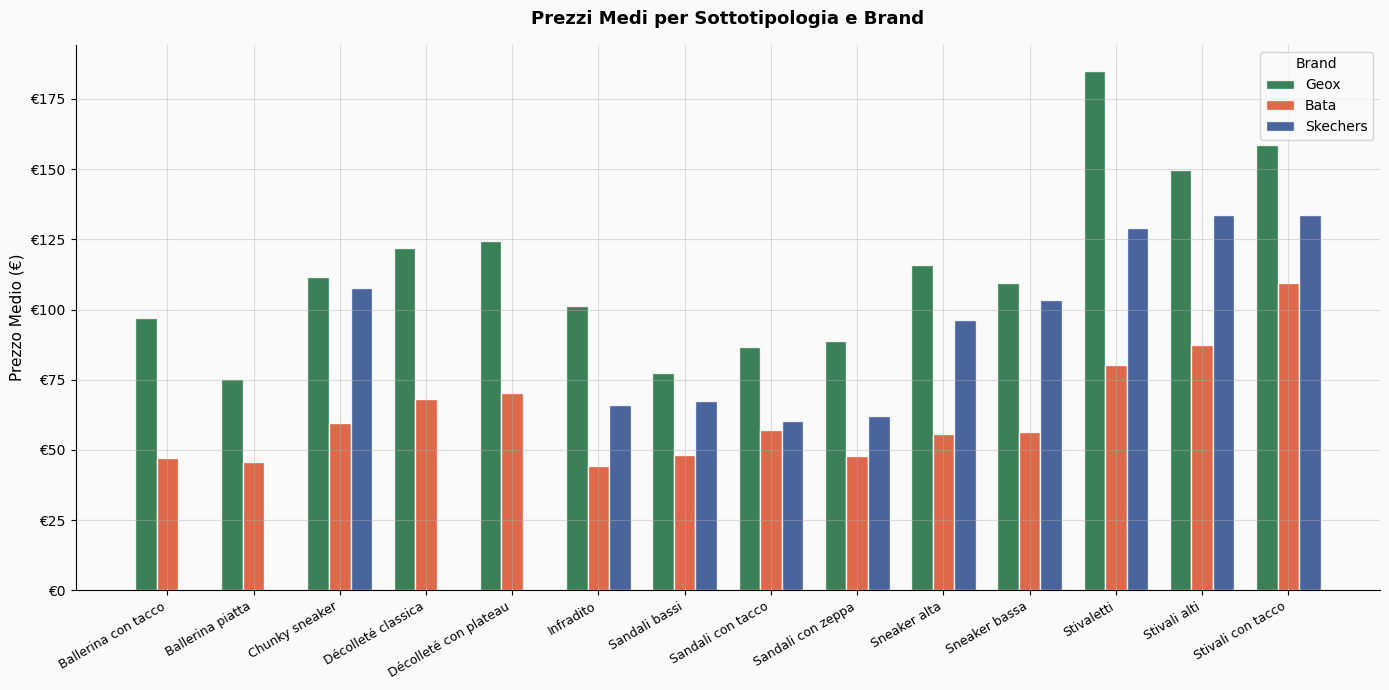

Salvato: grafico5_sottotipologie.png


In [29]:

# GRAFICO 5: Prezzi Medi per SOTTOTIPOLOGIA (top sottotipologie comuni)


# 1) Calcoliamo statistiche per ogni combinazione (sottotipologia, brand):
#    - mean  → prezzo medio
#    - count → numero di modelli
sub_stats = (
    df.groupby(['sottotipologia', 'brand'])['prezzo']
      .agg(['mean', 'count'])
      .reset_index()
)

# 2) Rinominiamo le colonne per chiarezza.
sub_stats.columns = ['sottotipologia', 'brand', 'prezzo_medio', 'n_modelli']

# 3) Selezioniamo solo le sottotipologie presenti in almeno 2 brand.
#    Questo evita sottotipi presenti in un solo brand, che non sarebbero confrontabili.
presenti = sub_stats.groupby('sottotipologia')['brand'].nunique()
top_sub = presenti[presenti >= 2].index.tolist()

# 4) Filtriamo il DataFrame sulle sole sottotipologie "comuni" (presenti in ≥ 2 brand).
sub_plot = sub_stats[sub_stats['sottotipologia'].isin(top_sub)]

# 5) Creiamo la figura.
fig, ax = plt.subplots(figsize=(14, 7))

# 6) Lista delle sottotipologie uniche da plottare (asse X).
sottotipi_unici = sub_plot['sottotipologia'].unique()

# 7) Posizioni sull’asse X e larghezza delle barre.
x = np.arange(len(sottotipi_unici))
width = 0.25

# 8) Cicliamo sui brand per costruire un bar chart raggruppato.
for i, brand in enumerate(BRAND_ORDER):
    vals = []

    # 8a) Per ogni sottotipologia, cerchiamo il prezzo medio di quel brand.
    #     Se il brand non ha quella sottotipologia → mettiamo 0 (barra assente).
    for st in sottotipi_unici:
        row = sub_plot[
            (sub_plot['sottotipologia'] == st) &
            (sub_plot['brand'] == brand)
        ]
        vals.append(row['prezzo_medio'].values[0] if len(row) > 0 else 0)

    # 8b) Disegniamo le barre per quel brand.
    ax.bar(
        x + i * width,
        vals,
        width=width,
        label=brand,
        color=COLORI_BRAND[brand],
        alpha=0.85,
        edgecolor='white'
    )

# 9) Configurazione asse X: etichette = nomi delle sottotipologie.
ax.set_xticks(x + width)
ax.set_xticklabels(sottotipi_unici, rotation=30, ha='right', fontsize=9)

# 10) Formattazione asse Y in euro.
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('€%.0f'))

# 11) Etichetta asse Y.
ax.set_ylabel('Prezzo Medio (€)', fontsize=11)

# 12) Titolo del grafico.
ax.set_title(
    'Prezzi Medi per Sottotipologia e Brand',
    fontsize=13,
    fontweight='bold',
    pad=15
)

# 13) Legenda dei brand.
ax.legend(title='Brand', framealpha=0.8)

# 14) Ottimizzazione layout e salvataggio.
plt.tight_layout()
plt.savefig('grafico5_sottotipologie.png', dpi=150, bbox_inches='tight')

# 15) Visualizzazione.
plt.show()

print("Salvato: grafico5_sottotipologie.png")


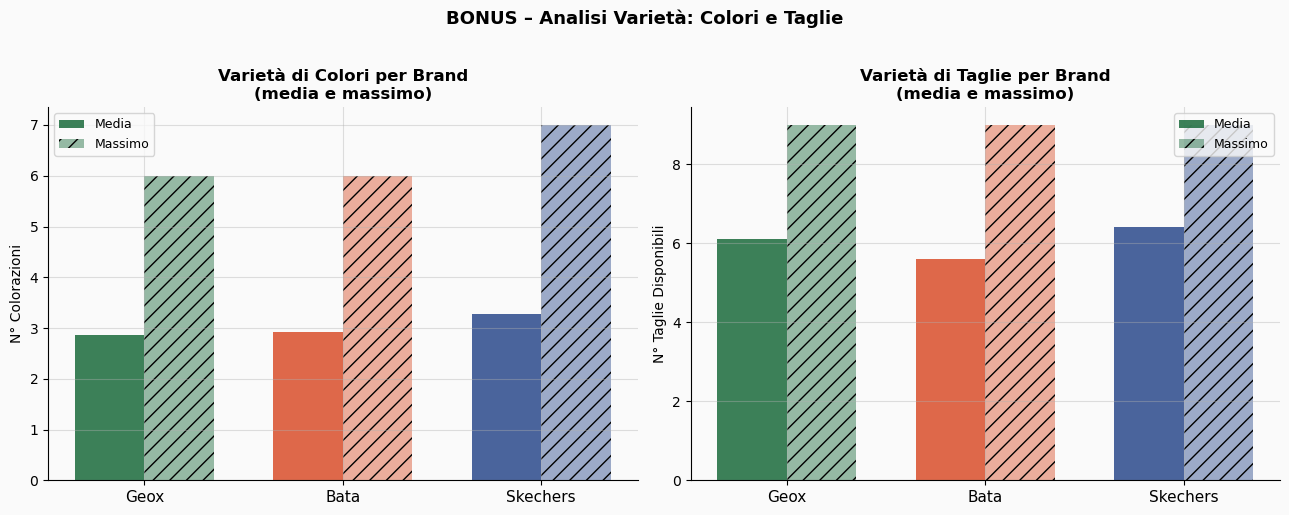

 Salvato: grafico6_bonus_colori_taglie.png


In [59]:

# GRAFICO 6 (BONUS): Varietà Colori e Taglie per Brand

# 1) Creiamo una figura con 2 sottografi affiancati:
#    - a sinistra: analisi colori
#    - a destra: analisi taglie

fig, axes = plt.subplots(1, 2, figsize=(13, 5))


#       SEZIONE COLORI


# 2) Calcoliamo, per ogni brand:
#    - mean → numero medio di colorazioni per modello
#    - max  → numero massimo di colorazioni per un singolo modello
colori_brand = (
    df.groupby('brand')['n_colori']
      .agg(['mean', 'max'])
      .reindex(BRAND_ORDER)
)

# 3) Selezioniamo l’asse sinistro (colori).
ax = axes[0]

# 4) Posizioni sull’asse X e larghezza barre.
x = np.arange(len(BRAND_ORDER))
width = 0.35

# 5) Prima serie di barre: media colorazioni per brand.
ax.bar(
    x - width/2,
    colori_brand['mean'],
    width,
    label='Media',
    color=[COLORI_BRAND[b] for b in BRAND_ORDER],
    alpha=0.85
)

# 6) Seconda serie di barre: massimo colorazioni per brand.
#    - hatch='//' per differenziare visivamente dalla media.
ax.bar(
    x + width/2,
    colori_brand['max'],
    width,
    label='Massimo',
    color=[COLORI_BRAND[b] for b in BRAND_ORDER],
    alpha=0.45,
    hatch='//'
)

# 7) Etichette asse X e Y + titolo del sottografico colori.
ax.set_xticks(x)
ax.set_xticklabels(BRAND_ORDER, fontsize=11)
ax.set_ylabel('N° Colorazioni', fontsize=10)
ax.set_title(
    'Varietà di Colori per Brand\n(media e massimo)',
    fontsize=12,
    fontweight='bold'
)
ax.legend(fontsize=9)

#       SEZIONE TAGLIE

# 8) Calcoliamo, per ogni brand:
#    - mean → numero medio di taglie disponibili
#    - max  → numero massimo di taglie per un modello
taglie_brand = (
    df.groupby('brand')['n_taglie']
      .agg(['mean', 'max'])
      .reindex(BRAND_ORDER)
)

# 9) Selezioniamo l’asse destro (taglie).

ax = axes[1]

# 10) Barre per la media delle taglie.

ax.bar(
    x - width/2,
    taglie_brand['mean'],
    width,
    label='Media',
    color=[COLORI_BRAND[b] for b in BRAND_ORDER],
    alpha=0.85
)

# 11) Barre per il massimo delle taglie.

ax.bar(
    x + width/2,
    taglie_brand['max'],
    width,
    label='Massimo',
    color=[COLORI_BRAND[b] for b in BRAND_ORDER],
    alpha=0.45,
    hatch='//'
)

# 12) Etichette asse X e Y + titolo del sottografico taglie.

ax.set_xticks(x)
ax.set_xticklabels(BRAND_ORDER, fontsize=11)
ax.set_ylabel('N° Taglie Disponibili', fontsize=10)
ax.set_title(
    'Varietà di Taglie per Brand\n(media e massimo)',
    fontsize=12,
    fontweight='bold'
)
ax.legend(fontsize=9)


#       TITOLO GLOBALE

# 13) Titolo complessivo della figura (entrambi i grafici).
plt.suptitle(
    'BONUS – Analisi Varietà: Colori e Taglie',
    fontsize=13,
    fontweight='bold',
    y=1.02
)

# 14) Ottimizzazione layout e salvataggio.
plt.tight_layout()
plt.savefig('grafico6_bonus_colori_taglie.png', dpi=150, bbox_inches='tight')

# 15) Visualizzazione.
plt.show()

print(" Salvato: grafico6_bonus_colori_taglie.png")


In breve: questo grafico mostra, per ogni brand, quanto è ampia l’offerta in termini di colori e taglie, sia come media che come massimo per modello—è il cuore dell’analisi “varietà assortimento” del bonus.

---
## 8.  Export dei Dati

Salviamo il dataset pulito in CSV e il report statistico in Excel.

In [32]:

# ESPORTAZIONE DATI: CSV COMPLETO + REPORT EXCEL MULTI-FOGLIO


# 1) Esporta l'intero DataFrame unificato in formato CSV.
#    - index=False → non salva l'indice come colonna
#    - encoding='utf-8-sig' → compatibile con Excel (evita problemi di caratteri accentati)
df.to_csv('dati_competitor_calzature.csv', index=False, encoding='utf-8-sig')
print("CSV salvato: dati_competitor_calzature.csv")

# 2) Crea un file Excel con più fogli usando ExcelWriter.
#    Usiamo 'openpyxl' come engine per garantire compatibilità con Excel moderno.
with pd.ExcelWriter('report_competitor.xlsx', engine='openpyxl') as writer:
    
    # 2a) Foglio "Dati Grezzi":
    #     - esporta il DataFrame principale
    #     - rimuove la colonna 'taglie' (lista) perché poco leggibile in Excel
    #     - errors='ignore' → se 'taglie' non esiste, non solleva errore
    df.drop(columns=['taglie'], errors='ignore').to_excel(
        writer,
        sheet_name='Dati Grezzi',
        index=False
    )
    
    # 2b) Foglio "Statistiche Prezzi":
    #     - esporta la tabella stats (es. media, min, max per brand/categoria)
    stats.to_excel(
        writer,
        sheet_name='Statistiche Prezzi'
    )
    
    # 2c) Foglio "Varietà Colori":
    #     - esporta la tabella colori_brand (media e massimo n_colori per brand)
    colori_brand.to_excel(
        writer,
        sheet_name='Varietà Colori'
    )
    
    # 2d) Foglio "Varietà Taglie":
    #     - esporta la tabella taglie_brand (media e massimo n_taglie per brand)
    taglie_brand.to_excel(
        writer,
        sheet_name='Varietà Taglie'
    )

# 3) Messaggio di conferma per il file Excel.
print("Excel salvato: report_competitor.xlsx")


CSV salvato: dati_competitor_calzature.csv
Excel salvato: report_competitor.xlsx


## 9.  Conclusioni e Raccomandazioni Strategiche

###  Principali Finding

| Aspetto               | Geox                    | Bata                     | Skechers                   |
|-----------------------|------------------------ |--------------------------|----------------------------|
| Posizionamento prezzo | **Premium** (€65–€220)  | **Mid-range** (€19–€149) | **Mid-premium** (€35–€165) |
| Punti di forza        | Qualità, brand italiano | Volume, accessibilità    | Comfort, sport lifestyle   |
| Ampiezza gamma        | Media                   | **Alta**                 | Alta                       |
| Varietà colori        | Media                   | Alta                     | **Molto alta**             |
| Varietà taglie        | Alta                    | Alta                     | Alta                       |

### Raccomandazioni per il Brand

1. **Gap di prezzo**: Esiste spazio nel segmento **€80–€120** per sandali con tacco e stivaletti, poco presidiato dai competitor con qualità percepita elevata.

2. **Colori**: Skechers supera tutti per varietà cromatica. Il brand dovrebbe ampliare la palette nelle categorie sneaker e sandali per attrarre clienti più giovani.

3. **Sottotipologie mancanti**: Nessun competitor offre una linea strutturata di **ballerine con tacco basso** a prezzo accessibile (< €70). Opportunità di nicchia.

4. **Taglie inclusive**: Valutare l'estensione della gamma taglie (38–42 standard → 35–45 esteso), area in cui Bata ha già un vantaggio.

5. **Slip-on e comfort**: Il segmento slip-on di Skechers è molto forte. Se il brand non è presente, considerare l'ingresso con una linea dedicata.

